<a href="https://colab.research.google.com/github/bindal-tanmay/AI-Powered-Real-Time-Arrhythmia-Detection-Alert-System/blob/main/model_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.metrics         import (confusion_matrix, classification_report,
                                     r2_score, roc_curve, auc)
from sklearn.utils           import class_weight

import tensorflow as tf
from tensorflow.keras.models    import Sequential, load_model
from tensorflow.keras.layers    import (Conv1D, MaxPooling1D, LSTM, Dense,
                                         Dropout, BatchNormalization, Flatten)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.utils     import to_categorical

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

# List the contents of the downloaded dataset directory
print("\nContents of the dataset directory:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat

Contents of the dataset directory:
/kaggle/input/heartbeat/ptbdb_abnormal.csv
/kaggle/input/heartbeat/ptbdb_normal.csv
/kaggle/input/heartbeat/mitbih_test.csv
/kaggle/input/heartbeat/mitbih_train.csv


In [24]:
DATA_DIR    = "/kaggle/input/heartbeat"   # path to Kaggle MIT-BIH folder
MODEL_PATH  = "ecg_lstm_best.h5"
FS          = 360                   # sampling frequency (Hz)
WINDOW      = 180                   # samples per beat window (±90 around R-peak)
N_CLASSES   = 5                     # AAMI: N, S, V, F, Q
BATCH_SIZE  = 64
EPOCHS      = 50

# AAMI class labels
CLASS_NAMES = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)',
               'F (Fusion)', 'Q (Unknown/Paced)']
CLASS_SHORT = ['N', 'S', 'V', 'F', 'Q']

# MIT-BIH → AAMI mapping
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q'
}
AAMI_IDX = {'N':0,'S':1,'V':2,'F':3,'Q':4}

In [25]:
def load_mitbih_csv(data_dir):
    train_path = os.path.join(data_dir, "mitbih_train.csv")
    test_path  = os.path.join(data_dir, "mitbih_test.csv")

    print("Loading MIT-BIH CSV files...")
    train_df = pd.read_csv(train_path, header=None)
    test_df  = pd.read_csv(test_path,  header=None)

    X_train = train_df.iloc[:, :-1].values.astype(np.float32)
    y_train = train_df.iloc[:,  -1].values.astype(int)
    X_test  = test_df.iloc[:,  :-1].values.astype(np.float32)
    y_test  = test_df.iloc[:,   -1].values.astype(int)

    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    return X_train, y_train, X_test, y_test


In [33]:
import os

print(f"Checking in DATA_DIR: {DATA_DIR}")
print(os.path.exists(os.path.join(DATA_DIR, "mitbih_train.csv")))
print(os.path.exists(os.path.join(DATA_DIR, "mitbih_test.csv")))

Checking in DATA_DIR: /kaggle/input/heartbeat
True
True


In [26]:
data_dir = "/kaggle/input/heartbeat"
X_train, y_train, X_test, y_test = load_mitbih_csv(data_dir)

Loading MIT-BIH CSV files...
Train: (87554, 187), Test: (21892, 187)


In [27]:
def plot_eda(X_train, y_train):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("MIT-BIH ECG — Exploratory Data Analysis", fontsize=14, fontweight='bold')

    # Class distribution
    ax = axes[0, 0]
    counts = pd.Series(y_train).value_counts().sort_index()
    ax.bar(CLASS_SHORT, counts.values,
           color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
    ax.set_title("Class Distribution (Train)")
    ax.set_ylabel("Count")

    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha='center', fontsize=9)

    # Sample beats for each class
    for cls_idx in range(5):
        r, c = divmod(cls_idx + 1, 3)
        ax = axes[r, c]
        sample = X_train[y_train == cls_idx][0]
        ax.plot(sample, linewidth=1.2,
                color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'][cls_idx])
        ax.set_title(f"Sample — {CLASS_NAMES[cls_idx]}")
        ax.set_xlabel("Samples")
        ax.set_ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

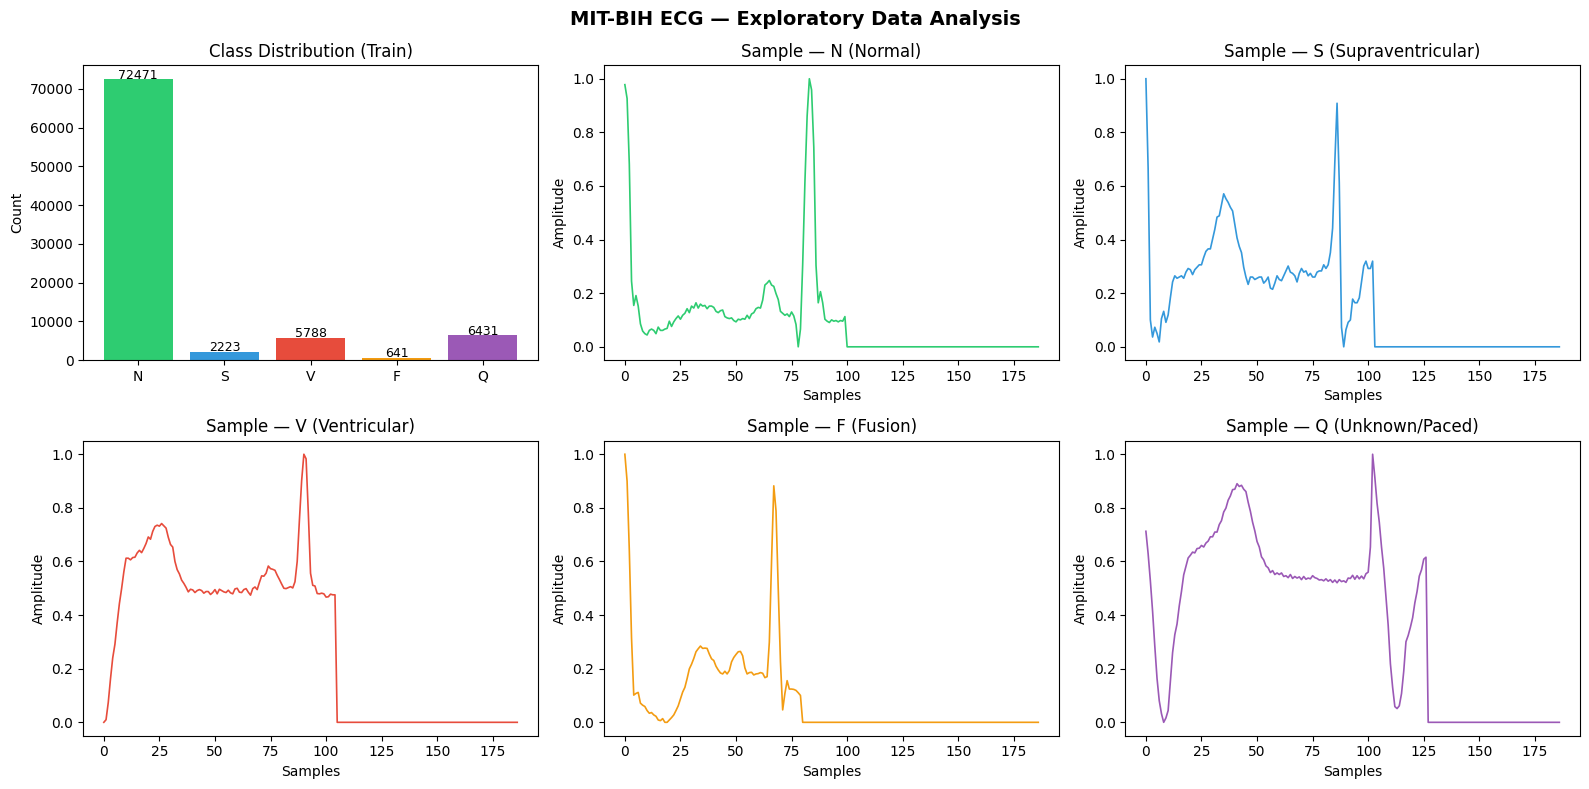

In [28]:
%matplotlib inline
plot_eda(X_train, y_train)

In [30]:
import os

print(os.path.exists("mitbih_train.csv"))
print(os.path.exists("mitbih_test.csv"))

False
False


In [16]:
# def plot_eda(X_train, y_train):
#     fig, axes = plt.subplots(2, 3, figsize=(16, 8))
#     fig.suptitle("MIT-BIH ECG — Exploratory Data Analysis", fontsize=14, fontweight='bold')

#     # Class distribution
#     ax = axes[0, 0]
#     counts = pd.Series(y_train).value_counts().sort_index()
#     ax.bar(CLASS_SHORT, counts.values, color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
#     ax.set_title("Class Distribution (Train)")
#     ax.set_ylabel("Count")
#     for i, v in enumerate(counts.values):
#         ax.text(i, v + 200, str(v), ha='center', fontsize=9)

#     # Sample beats for each class
#     for cls_idx in range(5):
#         r, c = divmod(cls_idx + 1, 3)
#         ax = axes[r, c]
#         sample = X_train[y_train == cls_idx][0]
#         ax.plot(sample, linewidth=1.2, color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'][cls_idx])
#         ax.set_title(f"Sample — {CLASS_NAMES[cls_idx]}")
#         ax.set_xlabel("Samples"); ax.set_ylabel("Amplitude")

#     plt.tight_layout()
#     plt.show()

In [19]:
# def build_model(input_shape):
#     model = Sequential([
#         # ── CNN frontend (local feature extraction) ──────────
#         Conv1D(filters=32, kernel_size=5, activation='relu', padding='same',
#                input_shape=input_shape),
#         BatchNormalization(),
#         Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling1D(pool_size=2),
#         Dropout(0.2),

#         Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling1D(pool_size=2),
#         Dropout(0.2),

#         # ── LSTM (temporal sequence modeling) ────────────────
#         LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
#         LSTM(64,  return_sequences=False, dropout=0.2, recurrent_dropout=0.1),

#         # ── Dense classifier ─────────────────────────────────
#         Dense(64, activation='relu'),
#         BatchNormalization(),
#         Dropout(0.3),
#         Dense(N_CLASSES, activation='softmax')
#     ])

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#         loss='categorical_crossentropy',
#         metrics=['accuracy',
#                  tf.keras.metrics.AUC(name='auc', multi_label=False)]
#     )

#     model.summary()
#     return model


In [20]:
# def train_model(model, X_tr, y_tr, X_val, y_val, class_weights):
#     callbacks = [
#         EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True,
#                       mode='max', verbose=1),
#         ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
#                           min_lr=1e-6, verbose=1),
#         ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True,
#                         mode='max', verbose=1)
#     ]

#     history = model.fit(
#         X_tr, y_tr,
#         validation_data=(X_val, y_val),
#         epochs=EPOCHS,
#         batch_size=BATCH_SIZE,
#         class_weight=class_weights,
#         callbacks=callbacks,
#         verbose=1
#     )
#     return history